# 🌦️ Apriori / FPGrowth – Weather Pattern Mining

**Mục tiêu:**
- KMeans clustering theo vùng (north/central/south)
- FPGrowth mining association rules dự báo rain & extreme events
- Toàn bộ dùng PySpark — **không `.toPandas()`**

## 0. Setup & Spark Session

In [1]:
import os, re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import NumericType, IntegerType, LongType, FloatType, DoubleType

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"]  = 11
PALETTE = ["#4e79a7","#f28e2b","#59a14f","#e15759","#76b7b2","#edc948","#b07aa1"]

aws_access_key    = os.getenv("AWS_ACCESS_KEY_ID",     "minioadmin")
aws_secret_key    = os.getenv("AWS_SECRET_ACCESS_KEY", "minioadmin123")
aws_region        = os.getenv("AWS_REGION",            "us-east-1")
minio_endpoint    = os.getenv("S3_ENDPOINT",           "http://minio:9000")
bronze_input_path = os.getenv("BRONZE_WEATHER_PATH",   "s3a://iceberg/bronze/weather_raw_parquet/")
spark_master      = os.getenv("SPARK_MASTER_URL",      "spark://spark-master:7077")
driver_host       = os.getenv("SPARK_DRIVER_HOST",     "forecasting-spark-notebook")

existing = SparkSession.getActiveSession()
if existing is not None:
    spark = existing
    print("♻️  Reusing existing SparkSession")
else:
    spark = (
        SparkSession.builder
        .appName("Weather-KMeans-Apriori")
        .master(spark_master)
        .config("spark.driver.host",        driver_host)
        .config("spark.driver.bindAddress", "0.0.0.0")
        .config("spark.sql.extensions",
                "org.apache.iceberg.spark.extensions.IcebergSparkSessionExtensions")
        .config("spark.sql.catalog.iceberg",                       "org.apache.iceberg.spark.SparkCatalog")
        .config("spark.sql.catalog.iceberg.type",                  "rest")
        .config("spark.sql.catalog.iceberg.uri",                   "http://iceberg-rest:8181")
        .config("spark.sql.catalog.iceberg.warehouse",             "s3://iceberg/warehouse")
        .config("spark.sql.catalog.iceberg.io-impl",               "org.apache.iceberg.aws.s3.S3FileIO")
        .config("spark.sql.catalog.iceberg.s3.endpoint",           minio_endpoint)
        .config("spark.sql.catalog.iceberg.s3.path-style-access",  "true")
        .config("spark.sql.catalog.iceberg.s3.access-key-id",      aws_access_key)
        .config("spark.sql.catalog.iceberg.s3.secret-access-key",  aws_secret_key)
        .config("spark.sql.catalog.iceberg.s3.region",             aws_region)
        .config("spark.hadoop.fs.s3a.endpoint",                    minio_endpoint)
        .config("spark.hadoop.fs.s3a.access.key",                  aws_access_key)
        .config("spark.hadoop.fs.s3a.secret.key",                  aws_secret_key)
        .config("spark.hadoop.fs.s3a.path.style.access",           "true")
        .config("spark.hadoop.fs.s3a.impl",                        "org.apache.hadoop.fs.s3a.S3AFileSystem")
        .config("spark.hadoop.fs.s3a.connection.ssl.enabled",      "false")
        .config("spark.hadoop.fs.s3a.fast.upload",                 "true")
        .config("spark.hadoop.fs.s3a.connection.maximum",          "100")
        .config("spark.hadoop.fs.s3a.attempts.maximum",            "3")
        .config("spark.hadoop.fs.s3a.connection.timeout",          "200000")
        .config("spark.hadoop.fs.s3a.socket.timeout",              "200000")
        .config("spark.hadoop.fs.s3a.aws.credentials.provider",
                "org.apache.hadoop.fs.s3a.SimpleAWSCredentialsProvider")
        .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
        .getOrCreate()
    )

spark.sparkContext.setLogLevel("ERROR")

df = spark.read.parquet(bronze_input_path)
assert "region" in df.columns, "Cột 'region' thiếu — chạy lại preprocessing.py"

n_rows = df.count()
print(f"✅ Loaded {n_rows:,} rows × {len(df.columns)} cols")
print(f"   Spark master : {spark_master}  |  MinIO: {minio_endpoint}")
df.printSchema()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/03 09:59:04 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
[Stage 1:>                                                          (0 + 2) / 3]

✅ Loaded 3,810,913 rows × 38 cols
   Spark master : spark://spark-master:7077  |  MinIO: http://minio:9000
root
 |-- time: string (nullable = true)
 |-- city: string (nullable = true)
 |-- temperature: string (nullable = true)
 |-- temp_min: string (nullable = true)
 |-- temp_max: string (nullable = true)
 |-- humidity: string (nullable = true)
 |-- feels_like: string (nullable = true)
 |-- visibility: string (nullable = true)
 |-- precipitation: string (nullable = true)
 |-- cloudcover: string (nullable = true)
 |-- wind_speed: string (nullable = true)
 |-- wind_gust: string (nullable = true)
 |-- wind_direction: string (nullable = true)
 |-- pressure: string (nullable = true)
 |-- is_day: string (nullable = true)
 |-- weather_code: string (nullable = true)
 |-- weather_main: string (nullable = true)
 |-- weather_description: string (nullable = true)
 |-- weather_icon: string (nullable = true)
 |-- hour: string (nullable = true)
 |-- day: string (nullable = true)
 |-- month: string (n

## 1. Phân Bố Theo Region
### 1.1 Số mẫu theo region

+-------+-------+
| region|  count|
+-------+-------+
|  north|1542197|
|  south|1206613|
|central|1062103|
+-------+-------+



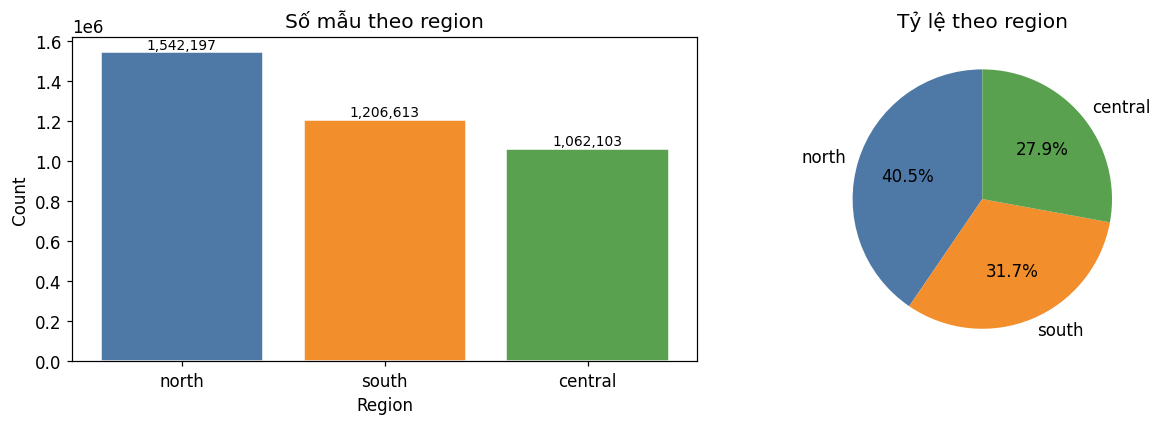

In [18]:
df.groupBy("region").count().orderBy(F.desc("count")).show()

# Chart — collect chỉ 3 rows (an toàn)
region_data = (df.groupBy("region").count()
                 .orderBy(F.desc("count"))
                 .collect())
regions = [r["region"] for r in region_data]
counts  = [r["count"]  for r in region_data]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(regions, counts, color=PALETTE[:len(regions)], edgecolor="white")
axes[0].set_title("Số mẫu theo region")
axes[0].set_xlabel("Region"); axes[0].set_ylabel("Count")
for bar, v in zip(axes[0].patches, counts):
    axes[0].text(bar.get_x()+bar.get_width()/2, v, f"{v:,}",
                 ha="center", va="bottom", fontsize=9)
axes[1].pie(counts, labels=regions, autopct="%1.1f%%",
            colors=PALETTE[:len(regions)], startangle=90)
axes[1].set_title("Tỷ lệ theo region")
plt.tight_layout()
plt.show()

### 1.2 Extreme events theo region

+-------+--------+-------+
| region| extreme|  count|
+-------+--------+-------+
|central|heatwave|  26740|
|central|  normal|1035363|
|  north|heatwave|  28171|
|  north|  normal|1514026|
|  south|heatwave|   4237|
|  south|  normal|1202376|
+-------+--------+-------+



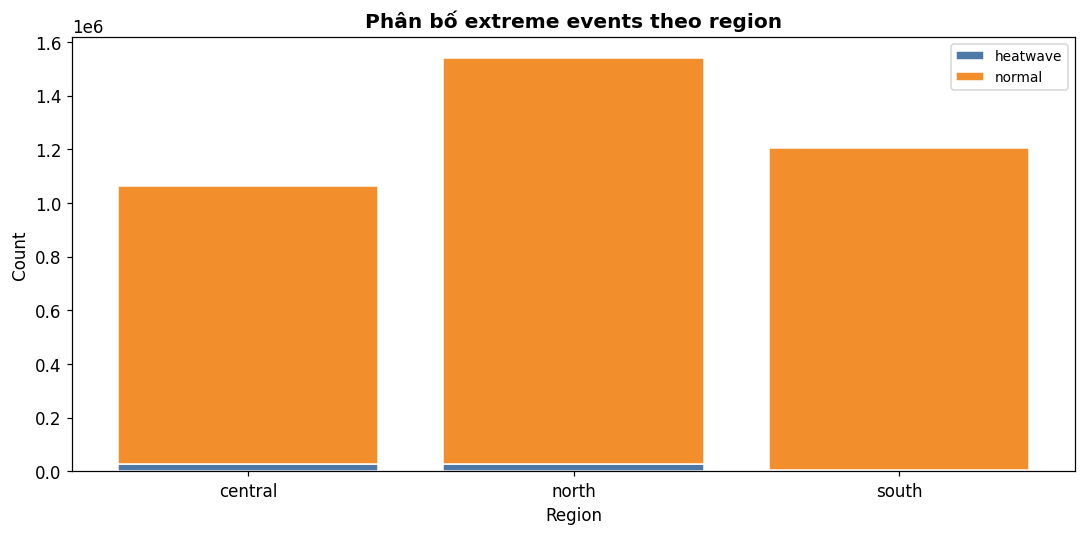

In [19]:
df.groupBy("region", "extreme").count().orderBy("region", "extreme").show(30)

# Stacked bar — collect matrix nhỏ
ext_data = (df.groupBy("region", "extreme").count()
              .orderBy("region", "extreme")
              .collect())

regions_u = sorted(set(r["region"] for r in ext_data))
extremes_u = sorted(set(r["extreme"] for r in ext_data))
val_map = {(r["region"], r["extreme"]): r["count"] for r in ext_data}

fig, ax = plt.subplots(figsize=(10, 5))
bottoms = [0] * len(regions_u)
for i, ext in enumerate(extremes_u):
    vals = [val_map.get((reg, ext), 0) for reg in regions_u]
    bars = ax.bar(regions_u, vals, bottom=bottoms,
                  color=PALETTE[i % len(PALETTE)], label=ext, edgecolor="white")
    bottoms = [b + v for b, v in zip(bottoms, vals)]

ax.set_title("Phân bố extreme events theo region", fontweight="bold")
ax.set_xlabel("Region"); ax.set_ylabel("Count")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

### 1.3 Tạo rain_label & phân bố

+-------+-----------+---------------+----------+-------+----------+
| region| temp_level| humidity_level|wind_level|extreme|rain_label|
+-------+-----------+---------------+----------+-------+----------+
|central|  temp_high|humidity_medium|  wind_low| normal|   rain_no|
|  south|temp_medium|  humidity_high|  wind_low| normal|   rain_no|
|  north|temp_medium|humidity_medium|  wind_low| normal|   rain_no|
|central|temp_medium|humidity_medium|  wind_low| normal|   rain_no|
|central|temp_medium|humidity_medium|  wind_low| normal|   rain_no|
|  north|temp_medium|  humidity_high|  wind_low| normal|   rain_no|
|  north|temp_medium|humidity_medium|  wind_low| normal|   rain_no|
|  south|temp_medium|  humidity_high|  wind_low| normal|  rain_yes|
|central|temp_medium|humidity_medium|  wind_low| normal|   rain_no|
|  north|temp_medium|humidity_medium|  wind_low| normal|   rain_no|
+-------+-----------+---------------+----------+-------+----------+
only showing top 10 rows



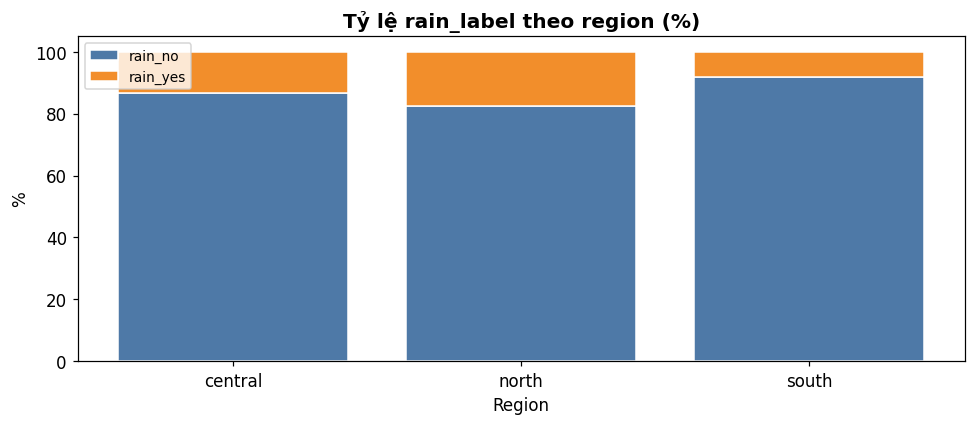

In [20]:
# Tạo rain_label từ precipitation
df = df.withColumn("rain_label",
    F.when(F.col("precipitation") > 0, "rain_yes").otherwise("rain_no")
)
df.select("region", "temp_level", "humidity_level", "wind_level",
          "extreme", "rain_label").show(10)

# Stacked 100% bar
rain_data = (df.groupBy("region", "rain_label").count()
               .orderBy("region", "rain_label")
               .collect())

regions_u2 = sorted(set(r["region"] for r in rain_data))
rain_labels = sorted(set(r["rain_label"] for r in rain_data))
rain_map = {(r["region"], r["rain_label"]): r["count"] for r in rain_data}

# Convert to percent
totals = {reg: sum(rain_map.get((reg, rl), 0) for rl in rain_labels) for reg in regions_u2}

fig, ax = plt.subplots(figsize=(9, 4))
bottoms = [0.0] * len(regions_u2)
for i, rl in enumerate(rain_labels):
    pcts = [rain_map.get((reg, rl), 0) / totals[reg] * 100 for reg in regions_u2]
    ax.bar(regions_u2, pcts, bottom=bottoms,
           color=PALETTE[i % len(PALETTE)], label=rl, edgecolor="white")
    bottoms = [b + v for b, v in zip(bottoms, pcts)]
ax.set_title("Tỷ lệ rain_label theo region (%)", fontweight="bold")
ax.set_ylabel("%"); ax.set_xlabel("Region")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 2. KMeans Clustering
### 2.1 Tìm k tối ưu (Elbow + Silhouette)

In [21]:
# ── Debug: xem toàn bộ schema để chọn đúng tên cột ─────────────────────────
from pyspark.sql.types import (NumericType, IntegerType, LongType,
                               FloatType, DoubleType, ShortType, ByteType)

print("=== ALL COLUMNS ===")
for f in df.schema.fields:
    print(f"  {f.name:<35} {f.dataType}")

# Detect num_cols từ schema thực tế
num_cols = [f.name for f in df.schema.fields
            if isinstance(f.dataType, (NumericType, IntegerType, LongType,
                                       FloatType, DoubleType, ShortType, ByteType))]

EXCLUDE = {"hour","day","month","weekday","rain","weather_code",
           "is_day","cluster","year","latitude","longitude"}
SUFFIX_EXCLUDE = ("_lag_1","_lag_2","_sin","_cos","_level","_code")

candidate_features = [c for c in num_cols
                      if c not in EXCLUDE
                      and not any(c.endswith(s) for s in SUFFIX_EXCLUDE)]

print(f"\n=== CANDIDATE NUMERIC FEATURES ({len(candidate_features)}) ===")
for c in candidate_features:
    dtype = df.schema[c].dataType
    # Kiểm tra null ratio và distinct count
    stats = df.select(
        F.sum(F.col(c).isNull().cast("int")).alias("nulls"),
        F.countDistinct(c).alias("distinct")
    ).collect()[0]
    print(f"  {c:<35} nulls={stats['nulls']:>6}  distinct={stats['distinct']:>6}")

print(f"\n→ Chọn features từ danh sách trên để dùng cho KMeans")

=== ALL COLUMNS ===
  time                                StringType()
  city                                StringType()
  temperature                         DoubleType()
  temp_min                            DoubleType()
  temp_max                            DoubleType()
  humidity                            DoubleType()
  feels_like                          DoubleType()
  visibility                          DoubleType()
  precipitation                       DoubleType()
  cloudcover                          DoubleType()
  wind_speed                          DoubleType()
  wind_gust                           DoubleType()
  wind_direction                      StringType()
  pressure                            DoubleType()
  is_day                              StringType()
  weather_code                        StringType()
  weather_main                        StringType()
  weather_description                 StringType()
  weather_icon                        StringType()
  hour     

  temperature                         nulls=     0  distinct=  2421


  temp_min                            nulls=     0  distinct=  2421


  temp_max                            nulls=     0  distinct=  2421


  humidity                            nulls=     0  distinct=    72


  feels_like                          nulls=     0  distinct=  3033


  visibility                          nulls=     0  distinct=  8037


  precipitation                       nulls=     0  distinct=   918


  cloudcover                          nulls=     0  distinct=   101


  wind_speed                          nulls=     0  distinct=  1410
  wind_gust                           nulls=     0  distinct=  2099
  pressure                            nulls=     0  distinct=    46
  temp_range                          nulls=     0  distinct=  2310

→ Chọn features từ danh sách trên để dùng cho KMeans


✅ KMeans features (9): ['temperature', 'temp_min', 'temp_max', 'temp_range', 'humidity', 'pressure', 'wind_speed', 'precipitation', 'cloudcover']
   Sample size: 764,354 rows


   Persisted: 764,354 rows

   k            WCSS    Silhouette
------------------------------------
   2       6383232.4        0.6853


   3       4340806.5        0.4664


   4       3855110.2        0.2847


   5       3433271.7        0.3060
   6       3071653.4        0.3380


   7       3110994.0        0.2799


   8       2716710.9        0.3176


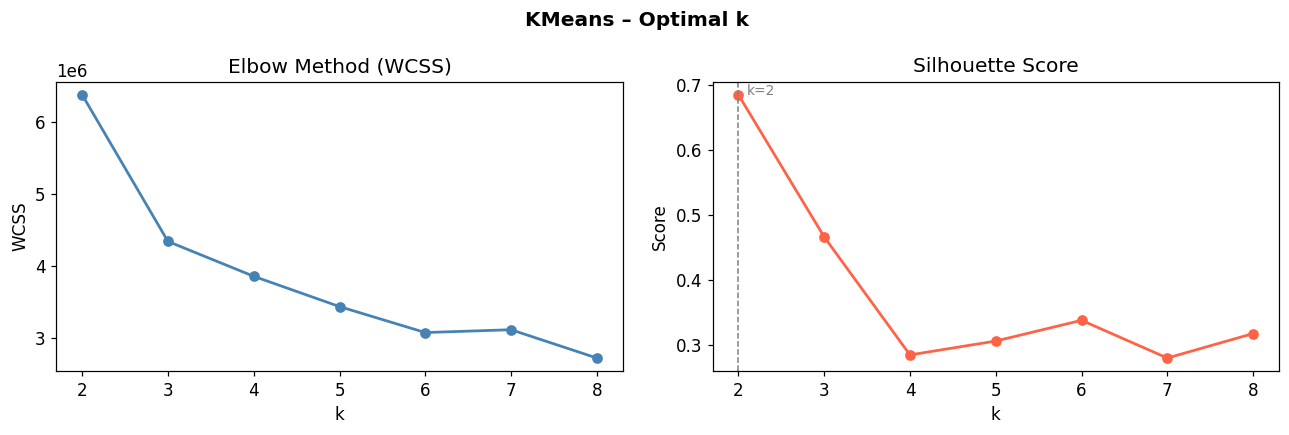


→ Suggested k = 2


In [22]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark import StorageLevel

SAMPLE_FRAC = 0.2
SEED        = 42
K_RANGE     = range(2, 9)

# ── Cast string → double (toàn bộ numeric bị lưu dạng string trong parquet) ───
NUMERIC_COLS = [
    "temperature","temp_min","temp_max","temp_range",
    "humidity","pressure","wind_speed","wind_gust",
    "precipitation","cloudcover","feels_like","visibility",
    "wind_dir_sin","wind_dir_cos",
]
df_cast = df
for c in NUMERIC_COLS:
    if c in df.columns:
        df_cast = df_cast.withColumn(c, F.col(c).cast("double"))

# Feature list: chỉ dùng cột tồn tại và có > 1 distinct
FEATURES_WANTED = [
    "temperature","temp_min","temp_max","temp_range",
    "humidity","pressure","wind_speed","precipitation","cloudcover"
]
features = []
for c in FEATURES_WANTED:
    if c not in df_cast.columns:
        continue
    n_distinct = df_cast.select(F.countDistinct(c)).collect()[0][0]
    if n_distinct > 1:
        features.append(c)
    else:
        print(f"  ⚠️  Bỏ '{c}' — chỉ có {n_distinct} distinct values")

print(f"✅ KMeans features ({len(features)}): {features}")

# ── Sample & pipeline ──────────────────────────────────────────────────────────
df_sample = df_cast.select(features).dropna().sample(fraction=SAMPLE_FRAC, seed=SEED)
n_sample  = df_sample.count()
print(f"   Sample size: {n_sample:,} rows")

assembler = VectorAssembler(inputCols=features, outputCol="features_raw",
                            handleInvalid="skip")
scaler    = StandardScaler(inputCol="features_raw", outputCol="features_scaled",
                           withMean=True, withStd=True)
df_vec    = assembler.transform(df_sample)
df_scaled = (scaler.fit(df_vec)
                   .transform(df_vec)
                   .select("features_scaled")
                   .persist(StorageLevel.MEMORY_AND_DISK))
print(f"   Persisted: {df_scaled.count():,} rows")

# ── Elbow + Silhouette ─────────────────────────────────────────────────────────
evaluator = ClusteringEvaluator(featuresCol="features_scaled",
                                metricName="silhouette",
                                distanceMeasure="squaredEuclidean")
wcss_list, sil_list = [], []

print(f"\n{'k':>4}  {'WCSS':>14}  {'Silhouette':>12}")
print("-" * 36)
for k in K_RANGE:
    model = KMeans(k=k, seed=SEED, maxIter=20, featuresCol="features_scaled").fit(df_scaled)
    pred  = model.transform(df_scaled)
    wcss  = model.summary.trainingCost
    sil   = evaluator.evaluate(pred)
    wcss_list.append(wcss); sil_list.append(sil)
    print(f"{k:>4}  {wcss:>14.1f}  {sil:>12.4f}")

df_scaled.unpersist()

ks = list(K_RANGE)
best_k = ks[sil_list.index(max(sil_list))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(ks, wcss_list, marker="o", color="steelblue", linewidth=1.8)
ax1.set_title("Elbow Method (WCSS)"); ax1.set_xlabel("k"); ax1.set_ylabel("WCSS")
ax2.plot(ks, sil_list, marker="o", color="tomato", linewidth=1.8)
ax2.axvline(best_k, color="gray", linestyle="--", linewidth=1)
ax2.text(best_k+0.1, max(sil_list), f"k={best_k}", color="gray", fontsize=9)
ax2.set_title("Silhouette Score"); ax2.set_xlabel("k"); ax2.set_ylabel("Score")
plt.suptitle("KMeans – Optimal k", fontweight="bold")
plt.tight_layout()
plt.show()
print(f"\n→ Suggested k = {best_k}")

### 2.2 Train KMeans với k tối ưu

In [25]:
BEST_K = best_k   # hoặc đặt tay: BEST_K = 3

# Cast string → double
NUMERIC_COLS = [
    "temperature","temp_min","temp_max","temp_range",
    "humidity","pressure","wind_speed","wind_gust",
    "precipitation","cloudcover","feels_like","visibility",
    "wind_dir_sin","wind_dir_cos",
]
df_cast = df
for c in NUMERIC_COLS:
    if c in df.columns:
        df_cast = df_cast.withColumn(c, F.col(c).cast("double"))

# Drop cột trung gian nếu đã tồn tại từ lần chạy trước
for tmp_col in ["features_raw", "features_scaled", "cluster", "prediction"]:
    if tmp_col in df_cast.columns:
        df_cast = df_cast.drop(tmp_col)

assembler_full = VectorAssembler(inputCols=features, outputCol="features_raw",
                                 handleInvalid="skip")
df_cast = assembler_full.transform(df_cast)

scaler_full = StandardScaler(inputCol="features_raw", outputCol="features_scaled",
                              withMean=True, withStd=True)
df_cast = scaler_full.fit(df_cast).transform(df_cast)

kmeans_model = KMeans(k=BEST_K, seed=42, maxIter=30,
                      featuresCol="features_scaled").fit(df_cast)
df = kmeans_model.transform(df_cast).withColumnRenamed("prediction", "cluster")

print(f"✅ KMeans done — k={BEST_K}")
df.groupBy("region", "cluster").count().orderBy("region", "cluster").show(30)

✅ KMeans done — k=2
+-------+-------+------+
| region|cluster| count|
+-------+-------+------+
|central|      0|648529|
|central|      1|413574|
|  north|      0|981196|
|  north|      1|561001|
|  south|      0|690697|
|  south|      1|515916|
+-------+-------+------+



### 2.3 Phân bố cluster theo region

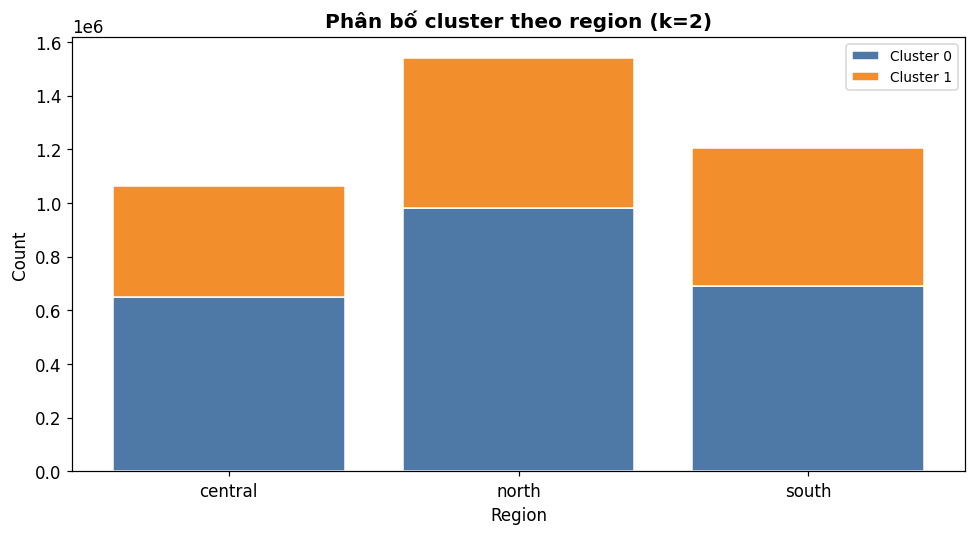


Cluster centroids (feature means):


[Stage 1298:>                                                       (0 + 2) / 3]

In [ ]:
# Stacked bar cluster × region
cluster_data = (df.groupBy("region", "cluster").count()
                  .orderBy("region", "cluster")
                  .collect())
regions_u3  = sorted(set(r["region"]  for r in cluster_data))
clusters_u  = sorted(set(r["cluster"] for r in cluster_data))
cl_map      = {(r["region"], r["cluster"]): r["count"] for r in cluster_data}

fig, ax = plt.subplots(figsize=(9, 5))
bottoms = [0] * len(regions_u3)
for i, cl in enumerate(clusters_u):
    vals = [cl_map.get((reg, cl), 0) for reg in regions_u3]
    ax.bar(regions_u3, vals, bottom=bottoms,
           color=PALETTE[i % len(PALETTE)], label=f"Cluster {cl}", edgecolor="white")
    bottoms = [b + v for b, v in zip(bottoms, vals)]
ax.set_title(f"Phân bố cluster theo region (k={BEST_K})", fontweight="bold")
ax.set_xlabel("Region"); ax.set_ylabel("Count")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Cluster centroids
print("\nCluster centroids (feature means):")
df.groupBy("cluster").agg(
    *[F.round(F.avg(F.col(c).cast("double")), 2).alias(c) for c in features]
).orderBy("cluster").show()

### 2.4 Cluster × Extreme events

In [ ]:
cl_ext_data = (df.groupBy("region", "cluster", "extreme").count()
                 .orderBy("region", "cluster", "extreme")
                 .collect())

regions_list = sorted(set(r["region"] for r in cl_ext_data))
fig, axes = plt.subplots(1, len(regions_list), figsize=(7*len(regions_list), 5))
if len(regions_list) == 1:
    axes = [axes]

for ax, region in zip(axes, regions_list):
    rows = [(r["cluster"], r["extreme"], r["count"])
            for r in cl_ext_data if r["region"] == region]
    clusters_r = sorted(set(r[0] for r in rows))
    extremes_r = sorted(set(r[1] for r in rows))
    val_m = {(r[0], r[1]): r[2] for r in rows}

    bottoms = [0] * len(clusters_r)
    x_pos = list(range(len(clusters_r)))
    for i, ext in enumerate(extremes_r):
        vals = [val_m.get((cl, ext), 0) for cl in clusters_r]
        ax.bar(x_pos, vals, bottom=bottoms,
               color=PALETTE[i % len(PALETTE)], label=ext, edgecolor="white")
        bottoms = [b + v for b, v in zip(bottoms, vals)]
    ax.set_title(f"{region.capitalize()}", fontweight="bold")
    ax.set_xlabel("Cluster"); ax.set_ylabel("Count")
    ax.set_xticks(x_pos); ax.set_xticklabels([f"Cl {c}" for c in clusters_r])
    ax.legend(fontsize=7)

plt.suptitle("Distribution extreme events by cluster × region", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3. FPGrowth – Association Rules
### 3.1 Build transaction items

In [ ]:
# Full items: tất cả features + target
df = df.withColumn(
    "items_full",
    F.array(
        F.col("temp_level"),
        F.col("humidity_level"),
        F.col("wind_level"),
        F.col("pressure_level"),
        F.concat(F.lit("cluster_"), F.col("cluster").cast("string")),
        F.col("rain_label"),
        F.col("extreme")
    )
)

# Context items: chỉ predictors (không có target)
df = df.withColumn(
    "items_ctx",
    F.array(
        F.col("temp_level"),
        F.col("humidity_level"),
        F.col("wind_level"),
        F.col("pressure_level"),
        F.concat(F.lit("cluster_"), F.col("cluster").cast("string"))
    )
)

df.select("region", "items_full").show(5, truncate=False)

# Split theo region
dfs_by_region = {
    "north"  : df.filter(F.col("region") == "north"),
    "central": df.filter(F.col("region") == "central"),
    "south"  : df.filter(F.col("region") == "south"),
}

# Chart: số transactions theo region — collect 3 rows
tx_counts = {reg: sub.count() for reg, sub in dfs_by_region.items()}
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(tx_counts.keys(), tx_counts.values(), color=PALETTE[:3], edgecolor="white")
ax.set_title("Số transactions theo region (sau split)", fontweight="bold")
ax.set_ylabel("Count")
for bar, v in zip(ax.patches, tx_counts.values()):
    ax.text(bar.get_x()+bar.get_width()/2, v, f"{v:,}",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

### 3.2 Chạy FPGrowth từng region

In [ ]:
from pyspark.ml.fpm import FPGrowth
from pyspark import StorageLevel

all_rules  = {}   # key=region, value=list of dicts (an toàn, không phải Pandas)
all_models = {}

TARGETS        = ["rain_yes", "heatwave", "heavy_rain", "storm"]
TARGET_EXTREME = ["heatwave", "heavy_rain", "storm"]

REGION_PARAMS = {
    "north"  : {"min_support": 0.005, "min_confidence": 0.1},
    "central": {"min_support": 0.005, "min_confidence": 0.1},
    "south": {"min_support": 0.001, "min_confidence": 0.05}
}

MAX_RULES = 200

# Filter: consequent phải là target
def is_target_consequent(consequent_list):
    return any(t in consequent_list for t in TARGETS)

n_parts = max(spark.sparkContext.defaultParallelism * 2, 32)
spark.conf.set("spark.sql.shuffle.partitions", str(n_parts))

for region, params in REGION_PARAMS.items():
    print(f"\n{'='*55}")
    print(f"  Region: {region.upper()}  |  {params}")
    print(f"{'='*55}")

    df_region = (
        dfs_by_region[region]
        .select("items_full")
        .filter(F.col("items_full").isNotNull())
        .repartition(n_parts)
        .persist(StorageLevel.MEMORY_AND_DISK)
    )
    tx_count = df_region.count()
    print(f"  Transactions: {tx_count:,}")

    fp = FPGrowth(itemsCol="items_full",
                  minSupport=params["min_support"],
                  minConfidence=params["min_confidence"],
                  numPartitions=n_parts)
    model = fp.fit(df_region)
    all_models[region] = model

    # Collect rules — đây là DataFrame nhỏ (< MAX_RULES rows)
    rules_df = model.associationRules

    # Filter chỉ lấy rules có consequent là target
    # Dùng UDF-free approach: explode + filter + groupby
    from pyspark.sql.functions import explode
    rules_filtered = (
        rules_df
        .filter(
            F.exists(F.col("consequent"), lambda x: x.isin(TARGETS))
        )
        .orderBy(F.desc("lift"))
        .limit(MAX_RULES)
    )

    # Collect về — số rows <= MAX_RULES, an toàn
    rows = rules_filtered.collect()
    all_rules[region] = [
        {
            "antecedent": list(r["antecedent"]),
            "consequent": list(r["consequent"]),
            "confidence": r["confidence"],
            "lift":       r["lift"],
            "support":    r["support"],
        }
        for r in rows
    ]

    print(f"  Rules found: {len(all_rules[region])}")
    if all_rules[region]:
        print(f"  Top 3 rules:")
        for rule in all_rules[region][:3]:
            print(f"    {rule['antecedent']} → {rule['consequent']}"
                  f"  conf={rule['confidence']:.3f}  lift={rule['lift']:.2f}")

    df_region.unpersist()

print("\n✅ FPGrowth done cho tất cả regions!")

### 3.3 Top frequent itemsets

In [ ]:
TOP_ITEMSETS = 10

for region, model in all_models.items():
    print(f"\n--- {region.upper()} — Top {TOP_ITEMSETS} frequent itemsets ---")
    model.freqItemsets.orderBy(F.desc("freq")).limit(TOP_ITEMSETS).show(truncate=False)

## 4. Visualizations
### 4.1 Support / Confidence / Lift scatter

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, region in zip(axes, ["north", "central", "south"]):
    rules = all_rules.get(region, [])
    ax.set_title(f"{region.capitalize()}", fontweight="bold")
    ax.set_xlabel("Support"); ax.set_ylabel("Confidence")

    if not rules:
        ax.text(0.5, 0.5, "Không có rules", ha="center", va="center",
                transform=ax.transAxes)
        continue

    xs = [r["support"]    for r in rules]
    ys = [r["confidence"] for r in rules]
    cs = [r["lift"]       for r in rules]

    sc = ax.scatter(xs, ys, c=cs, cmap="RdYlGn", alpha=0.7,
                    edgecolors="none", s=50)
    plt.colorbar(sc, ax=ax, label="Lift")

plt.suptitle("Support / Confidence / Lift — rules dự báo rain & extreme",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 4.2 Top 10 rules theo Lift (từng region)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, region in zip(axes, ["north", "central", "south"]):
    rules = all_rules.get(region, [])[:10]
    ax.set_title(f"{region.capitalize()} — Top 10 rules", fontweight="bold")

    if not rules:
        ax.text(0.5, 0.5, "Không có rules", ha="center", va="center",
                transform=ax.transAxes)
        ax.axis("off")
        continue

    labels = [
        f"{" + ".join(sorted(r["antecedent"])[:3])}\n→ {" + ".join(sorted(r["consequent"]))}"
        for r in rules
    ]
    lifts  = [r["lift"] for r in rules]
    colors = ["#d62728" if any(t in r["consequent"] for t in TARGET_EXTREME)
              else "#1f77b4" for r in rules]

    ax.barh(range(len(rules)), lifts, color=colors)
    ax.set_yticks(range(len(rules)))
    ax.set_yticklabels(labels, fontsize=6.5)
    ax.set_xlabel("Lift")
    ax.invert_yaxis()

legend_elements = [
    mpatches.Patch(facecolor="#d62728", label="Extreme event"),
    mpatches.Patch(facecolor="#1f77b4", label="Rain"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=2, fontsize=9)
plt.suptitle("Rules dự báo rain & extreme events theo region",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 4.3 Heatmap: average confidence theo antecedent item × region

In [ ]:
# Build dict: {(region, item): [confidence values]}
from collections import defaultdict

item_conf = defaultdict(list)
for region, rules in all_rules.items():
    for rule in rules:
        for item in rule["antecedent"]:
            item_conf[(region, item)].append(rule["confidence"])

if not item_conf:
    print("⚠️  Không có rules để vẽ heatmap.")
else:
    all_items   = sorted(set(k[1] for k in item_conf))
    all_regions = ["north", "central", "south"]

    matrix = []
    for item in all_items:
        row = []
        for reg in all_regions:
            vals = item_conf.get((reg, item), [])
            row.append(np.mean(vals) if vals else 0.0)
        matrix.append(row)

    matrix = np.array(matrix)

    fig, ax = plt.subplots(figsize=(10, max(5, len(all_items) * 0.4)))
    im = ax.imshow(matrix, aspect="auto", cmap="YlOrRd")
    ax.set_xticks(range(len(all_regions)))
    ax.set_xticklabels(all_regions)
    ax.set_yticks(range(len(all_items)))
    ax.set_yticklabels(all_items, fontsize=8)
    for i in range(len(all_items)):
        for j in range(len(all_regions)):
            ax.text(j, i, f"{matrix[i,j]:.2f}", ha="center", va="center",
                    fontsize=7, color="black" if matrix[i,j] < 0.5 else "white")
    plt.colorbar(im, ax=ax, label="Avg Confidence")
    ax.set_title("Avg confidence của antecedent items theo region", fontweight="bold")
    plt.tight_layout()
    plt.show()

### 4.4 Network graph rules

In [ ]:
import subprocess, sys

# Auto-install networkx nếu chưa có
try:
    import networkx as nx
    HAS_NX = True
    print(f"✅ networkx {nx.__version__} sẵn sàng")
except ImportError:
    print("📦 Đang cài networkx...")
    subprocess.check_call([sys.executable, "-m", "pip", "install",
                           "networkx", "--quiet", "--break-system-packages"])
    import networkx as nx
    HAS_NX = True
    print(f"✅ networkx {nx.__version__} đã cài xong")

# (import đã xử lý ở trên)

if HAS_NX:
    TARGET_EXTREME = ["heatwave", "heavy_rain", "storm"]
    TOP_N = 15
    MIN_LIFT = 1.5

    fig, axes = plt.subplots(1, 3, figsize=(26, 9))

    for ax, region in zip(axes, ["north", "central", "south"]):
        ax.set_title(f"{region.capitalize()} — Rules Network",
                     fontsize=12, fontweight="bold")
        ax.axis("off")

        rules = [r for r in all_rules.get(region, []) if r["lift"] >= MIN_LIFT][:TOP_N]
        if not rules:
            ax.text(0.5, 0.5, f"No rules with lift ≥ {MIN_LIFT}",
                    ha="center", va="center", transform=ax.transAxes)
            continue

        G = nx.DiGraph()
        for rule in rules:
            ant_items = sorted(rule["antecedent"])
            ant_label = "+".join(ant_items[:3])
            if len(ant_items) > 3:
                ant_label += f"+{len(ant_items)-3}more"
            for cons in rule["consequent"]:
                G.add_edge(ant_label, cons,
                           weight=rule["lift"],
                           confidence=rule["confidence"])

        # Node colors
        node_colors = []
        for node in G.nodes():
            if any(t in node for t in TARGET_EXTREME):
                node_colors.append("#d62728")
            elif "rain" in node:
                node_colors.append("#1f77b4")
            else:
                node_colors.append("#2ca02c")

        pos = nx.spring_layout(G, seed=42, k=2.5)
        edge_widths = [G[u][v]["weight"] * 0.4 for u, v in G.edges()]
        edge_colors = [plt.cm.RdYlGn(G[u][v]["confidence"]) for u, v in G.edges()]

        nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                               node_size=600, alpha=0.9)
        nx.draw_networkx_labels(G, pos, ax=ax, font_size=5.5)
        nx.draw_networkx_edges(G, pos, ax=ax, width=edge_widths,
                               edge_color=edge_colors, arrows=True,
                               arrowsize=15, alpha=0.8)

    legend_el = [
        mpatches.Patch(facecolor="#d62728", label="Extreme target"),
        mpatches.Patch(facecolor="#1f77b4", label="Rain target"),
        mpatches.Patch(facecolor="#2ca02c", label="Antecedent feature"),
    ]
    fig.legend(handles=legend_el, loc="lower center", ncol=3, fontsize=9)
    plt.suptitle("Association Rules Network Graph", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

## 5. Tổng Kết

In [ ]:
print("=" * 60)
print("TỔNG KẾT — KMEANS + FPGROWTH")
print("=" * 60)
print(f"\n📦 Dataset  : {n_rows:,} rows")
print(f"🔢 Features : {features}")
print(f"📍 KMeans k : {BEST_K}")

for region in ["north", "central", "south"]:
    rules = all_rules.get(region, [])
    n_rules = len(rules)
    if rules:
        best = rules[0]
        print(f"\n🔍 {region.upper():8s}: {n_rules} rules")
        print(f"   Best rule: {best['antecedent']} → {best['consequent']}")
        print(f"   conf={best['confidence']:.3f}  lift={best['lift']:.2f}  support={best['support']:.4f}")
    else:
        print(f"\n⚠️  {region.upper():8s}: Không tìm thấy rules — thử giảm min_support / min_confidence")

print("\n✅ Hoàn tất!")